<a href="https://colab.research.google.com/github/JuanMuneton87/Fundamentos_Ciencia_de_Datos/blob/main/Practicas/sp_3_Juan_Muneton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo

Juan Diego Muñetón Herrera

1017167910

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [42]:
import sklearn.datasets as datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga el conjunto de datos wine
vinos = datasets.load_wine()


In [43]:
#Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles.

df_vinos = pd.DataFrame(vinos.data, columns=vinos.feature_names)
df_vinos.info()
df_vinos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



## <span style="color:#2F749F;">Selecciona al menos tres variables numéricas para el análisis</span>

###- Variable 1: Proline
Media: 746.89

Std: 314.90

Min–Max: 278 – 1680

Tiene una escala muy grande, lo que hace que esta variable sea ideal para ver el comportamiento del escalamiento.

###- Variable 2: Flavanoids
Media: 2.03

Std: 0.99

Min–Max: 0.34 – 5.08

Su escala es pequeña, apropiada para ver como el escalamiento la pone al nivel de las otras.

###- Variable 3: Magnesium
Media: 99.74

Std: 14.28

Min–Max: 70 – 162

Escala intermedia, apropiada para comparar el escalamiento con las otras variables.



In [44]:
variables = ['proline', 'magnesium', 'flavanoids']
X = df_vinos[variables]

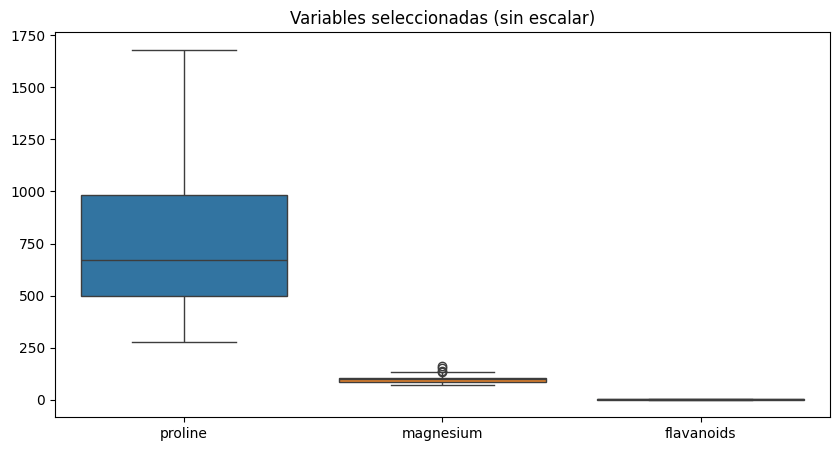

In [45]:
df_sel = df_vinos[variables]

plt.figure(figsize=(10,5))
sns.boxplot(data=df_sel)

plt.title("Variables seleccionadas (sin escalar)")
plt.show()

El Boxplot permite evidenciar el problema de escalamiento, y es que el uso de boxplots sobre variables sin escalar no permite una correcta visualización cuando existen diferencias significativas en la magnitud de las variables.

Por lo tanto, se emplean histogramas individuales para analizar la distribución original.

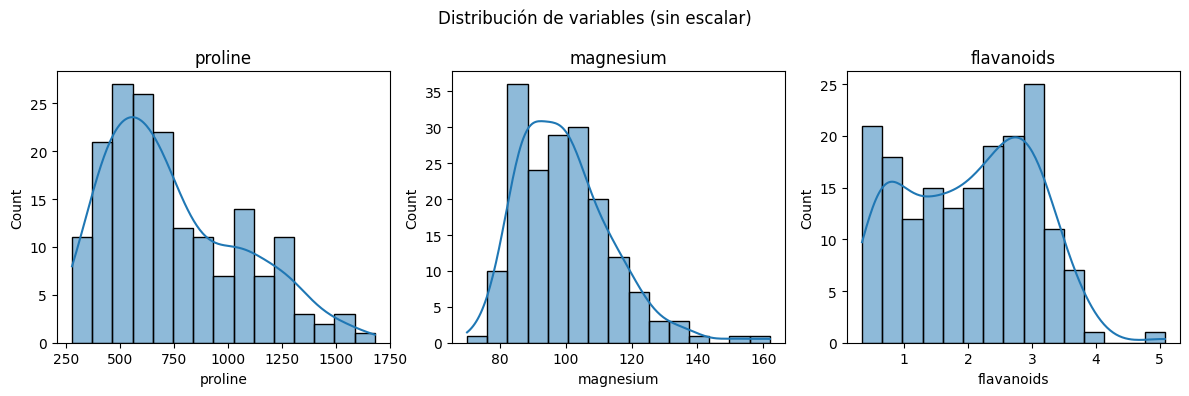

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i, col in enumerate(variables):
    sns.histplot(df_vinos[col], bins=15, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Distribución de variables (sin escalar)")
plt.tight_layout()
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

#Aplica los métodos de escalamiento sobre las variables seleccionadas

#StandardScaler
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)

df_standard = pd.DataFrame(X_standard, columns=variables)

#MinMaxScaler
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

df_minmax = pd.DataFrame(X_minmax, columns=variables)

#RobustScaler
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

df_robust = pd.DataFrame(X_robust, columns=variables)

#Z-Score
df_zscore = (X - X.mean()) / X.std()

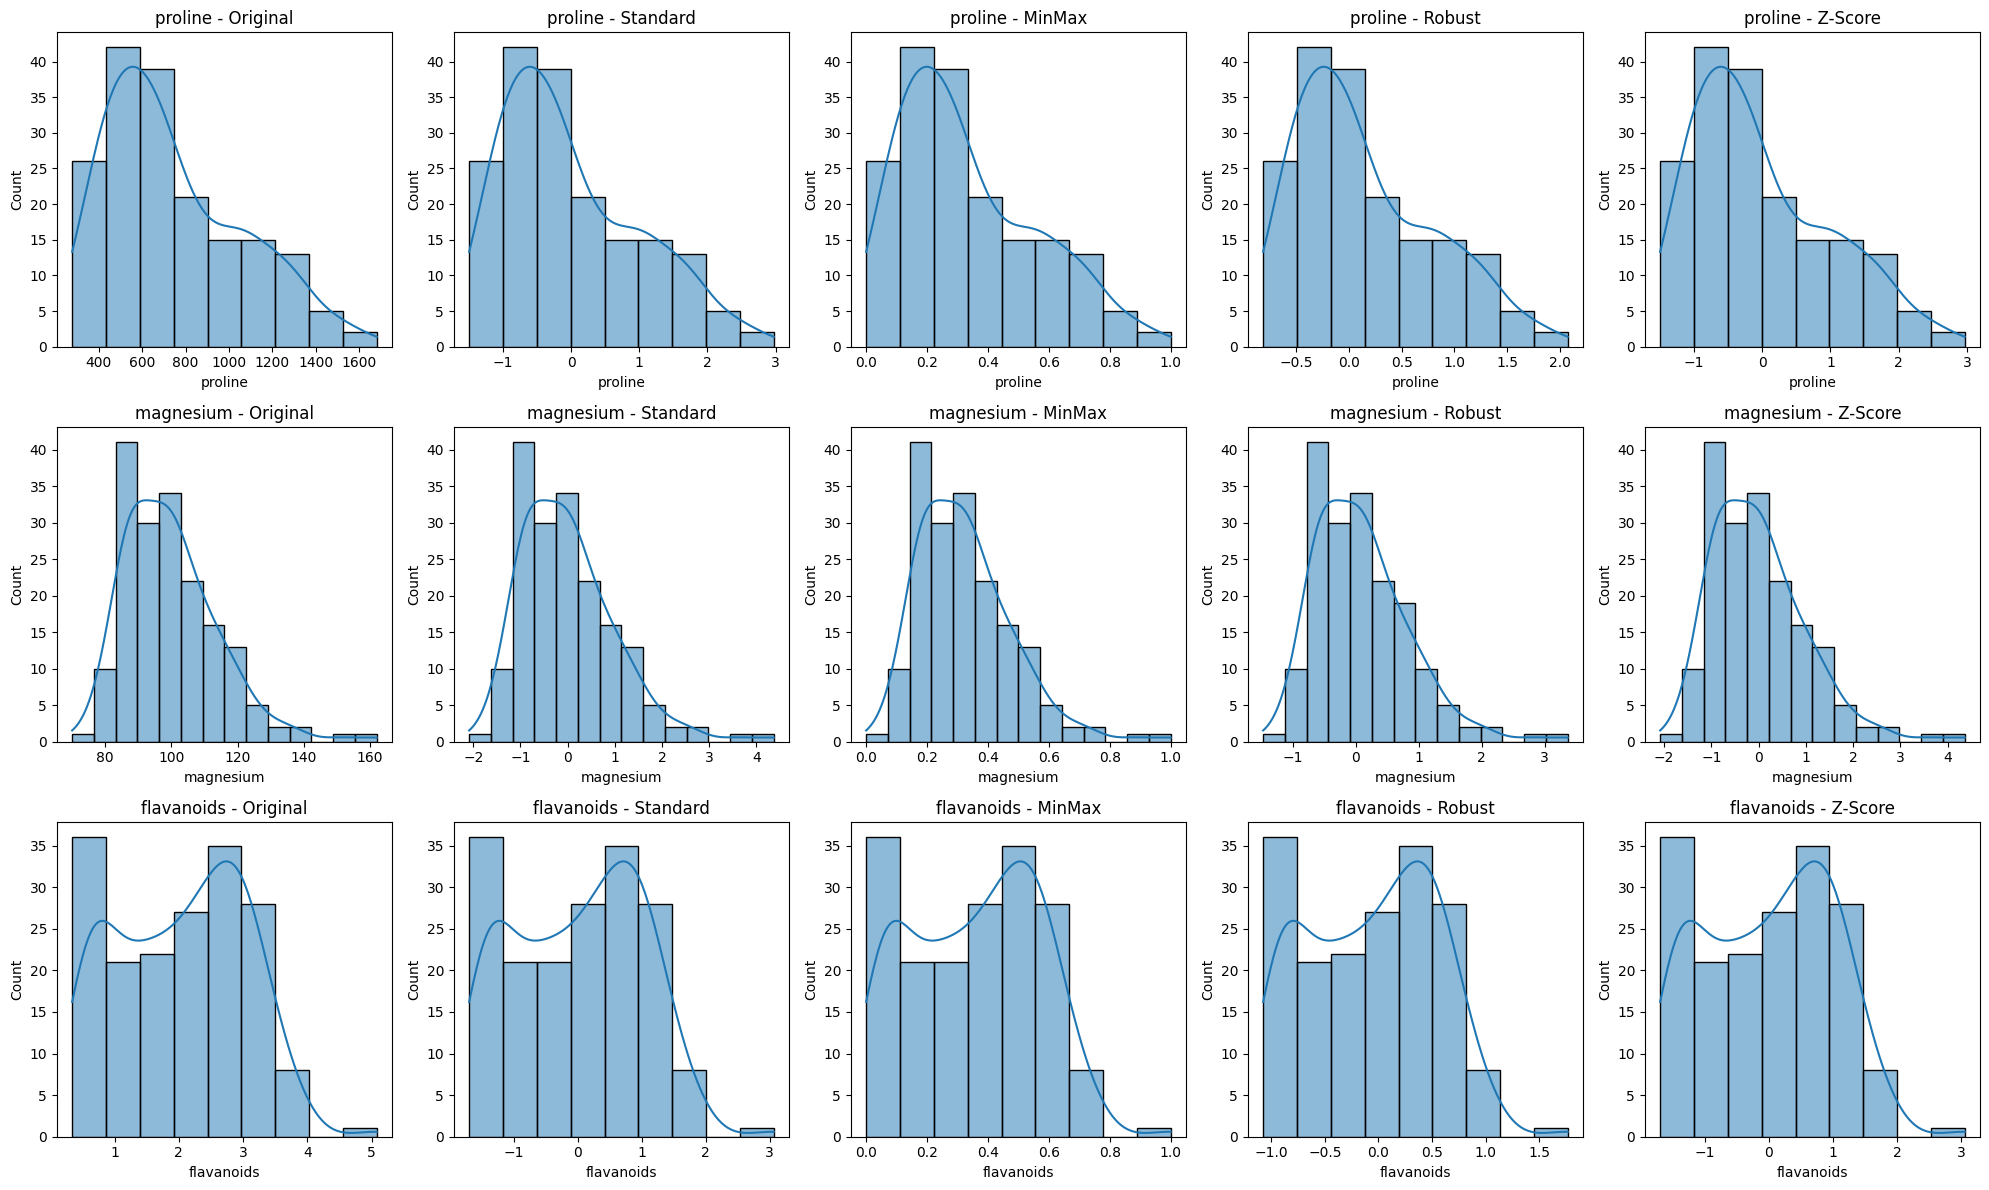

In [48]:
#Genera gráficas comparativas que permitan visualizar la distribución de al menos una de las variables seleccionadas

fig, axes = plt.subplots(3, 5, figsize=(20, 12))

datasets = [
    df_vinos,
    df_standard,
    df_minmax,
    df_robust,
    df_zscore
]

titulos = ["Original", "Standard", "MinMax", "Robust", "Z-Score"]
variables = ['proline', 'magnesium', 'flavanoids']

for i, var in enumerate(variables):
    for j, data in enumerate(datasets):
        sns.histplot(data[var], kde=True, ax=axes[i, j])
        axes[i, j].set_title(f"{var} - {titulos[j]}")

plt.tight_layout()
plt.show()

El escalamiento de datos no transforma la estructura interna de la información, sino que redefine su representación numérica. Su principal aporte radica en eliminar sesgos derivados de la magnitud de las variables, permitiendo que cada característica contribuya de manera equitativa en el análisis.

El efecto del escalamiento varía significativamente entre variables dependiendo de su escala, dispersión y presencia de valores extremos. En este caso, proline evidencia una fuerte dependencia del método de escalamiento debido a su alta variabilidad y asimetría, mientras que magnesium y flavanoids presentan comportamientos más estables.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [49]:
#Carga el conjunto de datos diabetes desde la librería

import sklearn.datasets as datasets

diabetes = datasets.load_diabetes()


In [82]:
#Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles.

df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes.target
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [51]:
#Selecciona al menos tres variables numéricas para el análisis

variables = ['bmi', 's5', 's1']
X = df_diabetes[variables]

X.head()

,bmi,s5,s1
0,0.061696,0.019907,-0.044223
1,-0.051474,-0.068332,-0.008449
2,0.044451,0.002861,-0.045599
3,-0.011595,0.022688,0.012191
4,-0.036385,-0.031988,0.003935


In [52]:
#Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:

#StandardScaler (Z-Score).
scaler_standard = StandardScaler()
X_zscore = scaler_standard.fit_transform(X)

df_zscore = pd.DataFrame(X_zscore, columns=variables)
df_zscore.head()

#RobustScaler (basado en mediana e IQR).
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

df_robust = pd.DataFrame(X_robust, columns=variables)
df_robust.head()

,bmi,s5,s1
0,1.053498,0.332755,-0.637363
1,-0.674897,-1.010756,-0.065934
2,0.790123,0.073213,-0.659341
3,-0.065844,0.375087,0.263736
4,-0.444444,-0.457391,0.131868


In [53]:
df_zscore.describe()
df_robust.describe()

,bmi,s5,s1
count,442.000000,4.420000e+02,442.000000
mean,0.111241,2.964727e-02,0.069017
std,0.727263,7.250389e-01,0.760617
min,-1.267490,-1.890285e+00,-1.956044
25%,-0.411523,-4.765441e-01,-0.478022
50%,0.000000,-1.734723e-18,0.000000
75%,0.588477,5.234559e-01,0.521978
max,2.716049,2.063775e+00,2.527473


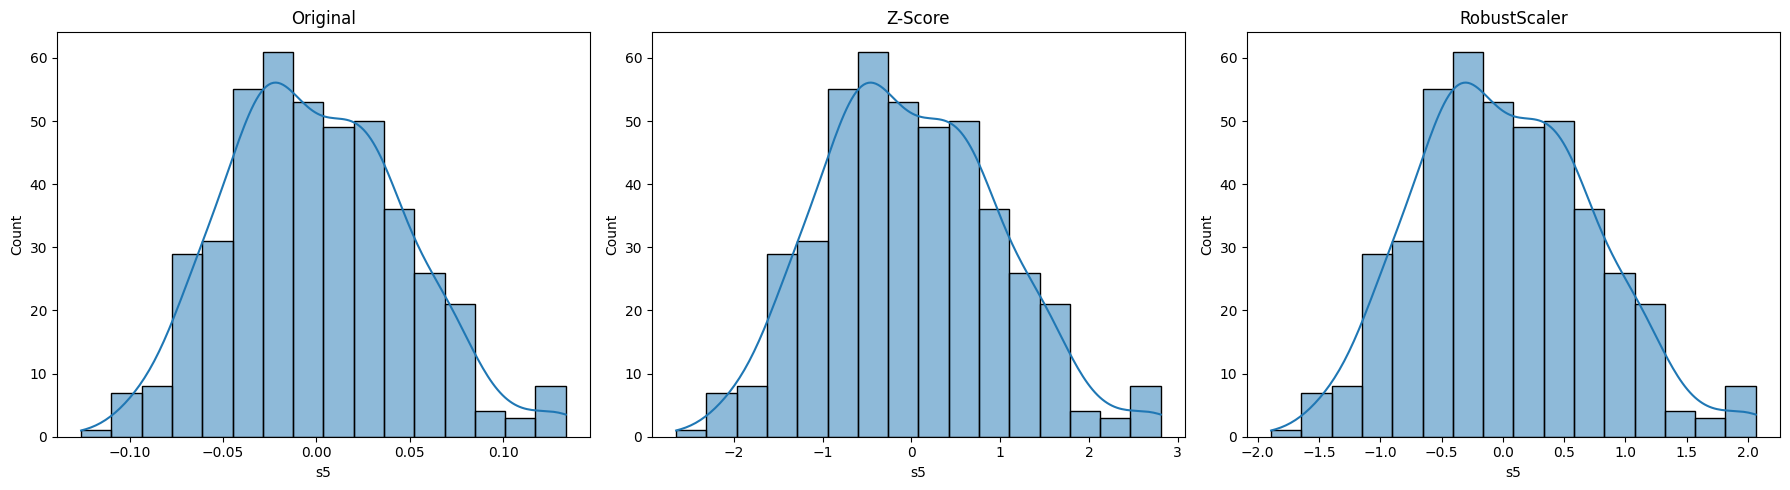

In [54]:
#Genera gráficas comparativas que permitan visualizar la distribución de al menos una de las variables seleccionadas en los siguientes escenarios

variable = 's5'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
sns.histplot(df_diabetes[variable], kde=True, ax=axes[0])
axes[0].set_title('Original')

# Z-Score
sns.histplot(df_zscore[variable], kde=True, ax=axes[1])
axes[1].set_title('Z-Score')

# RobustScaler
sns.histplot(df_robust[variable], kde=True, ax=axes[2])
axes[2].set_title('RobustScaler')

plt.tight_layout()
plt.show()

## <span style="color:#2F749F;"><strong>Análisis</strong></span>

En los resultados obtenidos, se observa que ambas técnicas mantienen la forma de la distribución, pero Z-Score presenta una mayor dispersión en presencia de outliers. Por su parte, RobustScaler concentra más los datos sin distorsionar significativamente la estructura general. En este caso, considerando la posible presencia de valores atípicos en la variable analizada, RobustScaler resulta más recomendable, ya que ofrece una escala más robusta y menos sensible a valores extremos, facilitando un análisis más fiable.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [55]:
#Carga el conjunto de datos California Housing

from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

In [81]:
#Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles.

df_housing = pd.DataFrame(california.data, columns=california.feature_names)
df_housing['target'] = california.target
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [57]:
#Selecciona al menos tres variables numéricas para el análisis

variables = ['MedInc', 'Population', 'AveRooms']
X = df_housing[variables]

In [58]:
#Aplica los siguientes métodos de normalización sobre las variables seleccionadas

from sklearn.preprocessing import Normalizer

#Normalización L1
normalizer_l1 = Normalizer(norm='l1')
X_l1 = normalizer_l1.fit_transform(X)

df_l1 = pd.DataFrame(X_l1, columns=variables)
df_l1.head()

#Normalización L2
normalizer_l2 = Normalizer(norm='l2')
X_l2 = normalizer_l2.fit_transform(X)

df_l2 = pd.DataFrame(X_l2, columns=variables)
df_l2.head()

,MedInc,Population,AveRooms
0,0.025840,0.999431,0.021677
1,0.003457,0.999991,0.002598
2,0.014628,0.999753,0.016706
3,0.010112,0.999895,0.010424
4,0.006807,0.999915,0.011117


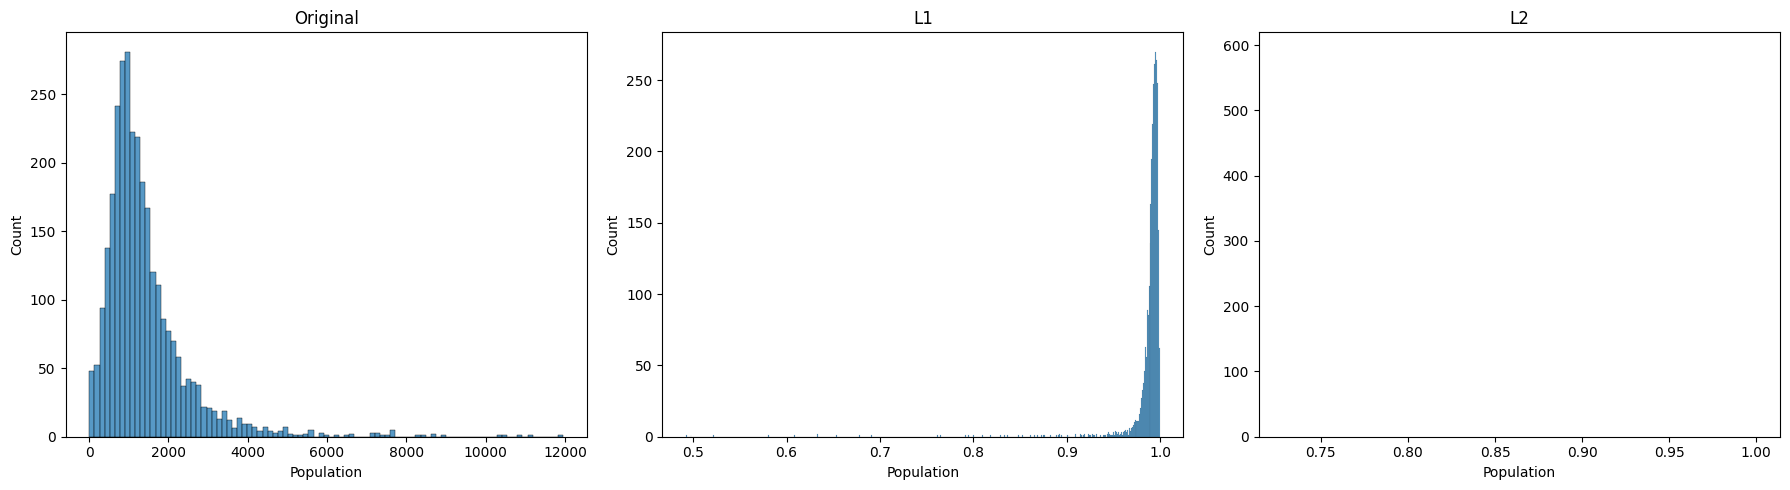

In [60]:
#Genera gráficas comparativas que permitan visualizar la distribución de al menos una de las variables seleccionadas en los siguientes escenarios:

variable = 'Population'

sample_size = 3000

data_original = df_housing[variable].sample(sample_size, random_state=42)
data_l1 = df_l1[variable].sample(sample_size, random_state=42)
data_l2 = df_l2[variable].sample(sample_size, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Distribución original
sns.histplot(data_original, ax=axes[0])
axes[0].set_title('Original')

#Distribución con normalización L1
sns.histplot(data_l1, ax=axes[1])
axes[1].set_title('L1')

#Distribución con normalización L2
sns.histplot(data_l2, ax=axes[2])
axes[2].set_title('L2')

plt.tight_layout()
plt.show()

In [63]:
df_l2['Population'].describe()

,Population
count,20640.000000
mean,0.999318
std,0.013338
min,0.206814
25%,0.999962
50%,0.999985
75%,0.999994
max,1.000000


## <span style="color:#2F749F;"><strong>Análisis</strong></span>

La normalización L1 distribuye el peso de manera más equilibrada entre las variables, reduciendo la relevancia de aquellas con mayor magnitud. Por otra parte, la normalización L2 conserva las diferencias relativas, lo que genera que variables como Population dominen casi completamente el vector normalizado. Esto se evidencia en la alta concentración de valores cercanos a 1 en L2. Entonces, L1 permite una representación más balanceada, mientras que L2 mantiene la estructura relativa de los datos. En este caso, L1 es más recomendable, ya que evita que una sola variable determine el comportamiento del conjunto.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [64]:
#Carga el conjunto de datos diabetes

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [80]:
#Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles.

df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  0 non-null      object 
dtypes: float64(10), object(1)
memory usage: 38.1+ KB


In [67]:
#Selecciona al menos dos variables numéricas para el análisis

variables = ['s5', 's1']
X = df_diabetes[variables]

In [69]:
#Aplica las siguientes transformaciones sobre una de las variables seleccionadas:
variable = 's5'
x = df_diabetes[variable]

#Transformación logarítmica usando np.log() o np.log1p()
x_shifted = x - x.min() + 1
x_log = np.log(x_shifted)

#Transformación logarítmica reflejada (útil cuando existe asimetría negativa)
x_reflect = x.max() - x + 1
x_log_reflect = np.log(x_reflect)

#Transformación cuadrática usando x²
x_sq = x ** 2

#Transformación Box-Cox usando scipy.stats.boxcox
from scipy.stats import boxcox
x_boxcox, lambda_bc = boxcox(x_shifted)

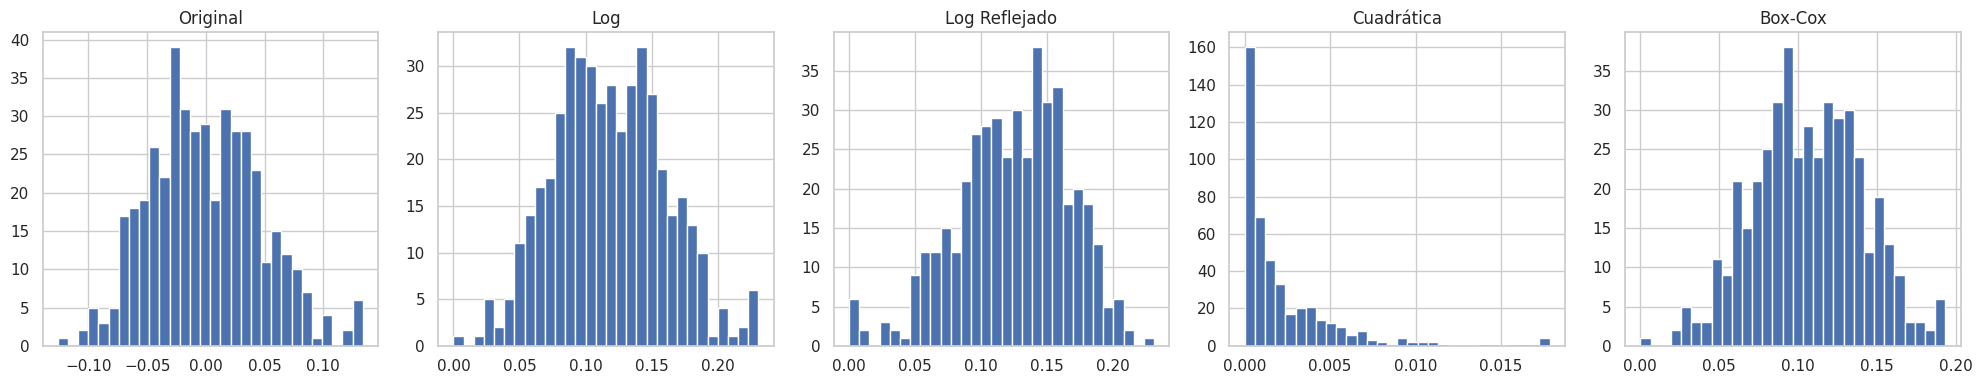

In [70]:
#Genera gráficas comparativas que permitan visualizar la distribución de la variable en los siguientes escenarios:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
bins = 30

#Distribución original
axes[0].hist(x, bins=bins)
axes[0].set_title('Original')

#Distribución con transformación log
axes[1].hist(x_log, bins=bins)
axes[1].set_title('Log')

#Distribución con log reflejado
axes[2].hist(x_log_reflect, bins=bins)
axes[2].set_title('Log Reflejado')

#Distribución con transformación cuadrática
axes[3].hist(x_sq, bins=bins)
axes[3].set_title('Cuadrática')

#Distribución con transformación Box-Cox
axes[4].hist(x_boxcox, bins=bins)
axes[4].set_title('Box-Cox')

plt.tight_layout()
plt.show()

## <span style="color:#2F749F;"><strong>Análisis</strong></span>

Las transformaciones aplicadas muestran comportamientos distintos sobre la distribución: la logarítmica reduce parcialmente la asimetría positiva, mientras que la log reflejada invierte la distribución, siendo más útil en casos de sesgo negativo. La transformación cuadrática amplifica las diferencias y aumenta el sesgo, generando una distribución más concentrada en valores bajos. Por otro lado, la transformación Box-Cox logra una distribución más simétrica y cercana a la normalidad. En consecuencia, Box-Cox es la más recomendable, ya que optimiza la transformación y mejora significativamente la forma de la distribución.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos Heart Disease desde la librería ucimlrepo usando load_dataset("heart_disease = fetch_ucirepo(id=45)")

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [78]:
#Carga el conjunto de datos Heart Disease desde la librería ucimlrepo usando load_dataset("heart_disease = fetch_ucirepo(id=45)")
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)

In [79]:
#Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles.
df_heart = heart_disease.data.features
df_heart['target'] = heart_disease.data.targets
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [83]:
#Selecciona al menos dos variables numéricas para el análisis

variables = ['chol', 'trestbps', 'oldpeak']
df_sel = df_heart[variables]

In [85]:
from sklearn.preprocessing import PowerTransformer
#Aplica las siguientes transformaciones sobre una de las variables seleccionadas:
variable = 'chol'
x = df_heart[variable]

#Raíz cuadrada usando np.sqrt()
x_sqrt = np.sqrt(x)

#Recíproca usando 1/x
x_reciprocal = 1 / (x + 1)

#Transformación Yeo-Johnson usando PowerTransformer(method="yeo-johnson")
pt = PowerTransformer(method='yeo-johnson')
x_yeojohnson = pt.fit_transform(x.values.reshape(-1, 1))

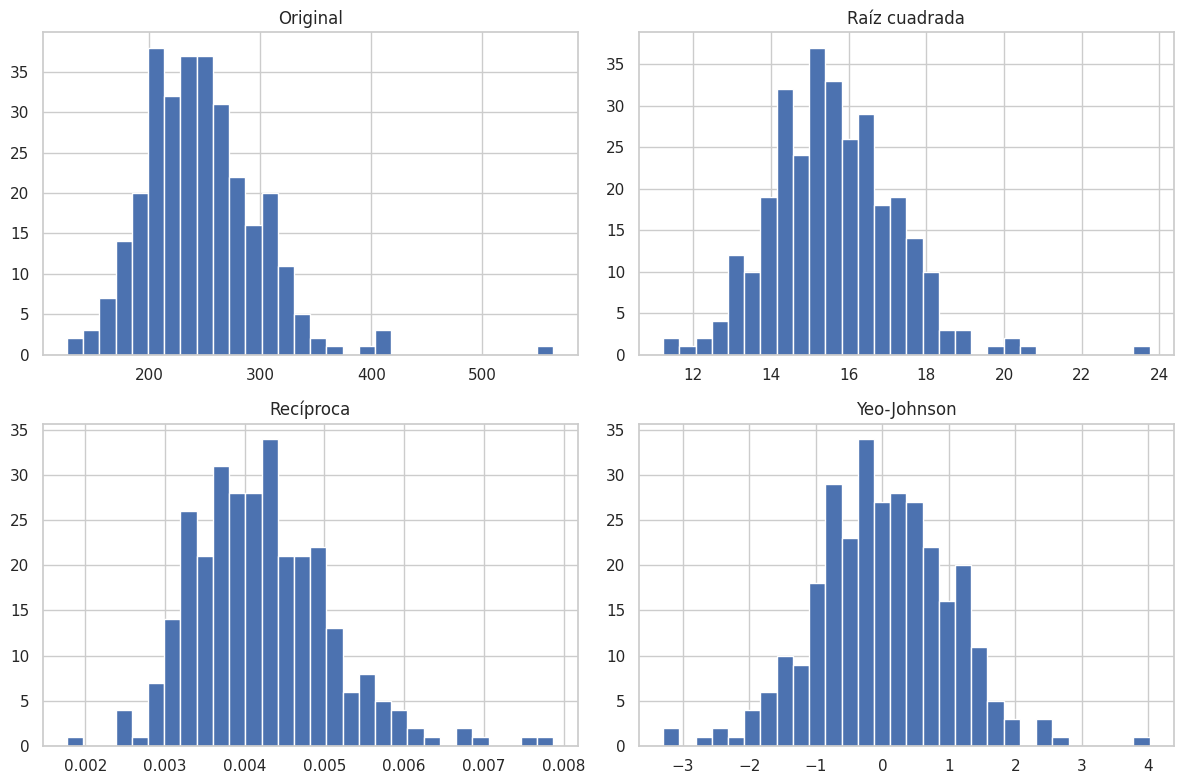

In [87]:
#Genera gráficas comparativas que permitan visualizar la distribución de la variable en los siguientes escenarios:

# Crear DataFrame con todas las transformaciones
df_trans = pd.DataFrame({
    'Original': x,
    'Raiz_cuadrada': x_sqrt,
    'Reciproca': x_reciprocal,
    'Yeo_Johnson': x_yeojohnson.flatten()
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#Distribución original
axes[0, 0].hist(df_trans['Original'], bins=30)
axes[0, 0].set_title('Original')

#Distribución con transformación raíz cuadrada
axes[0, 1].hist(df_trans['Raiz_cuadrada'], bins=30)
axes[0, 1].set_title('Raíz cuadrada')

#Distribución con transformación recíproca
axes[1, 0].hist(df_trans['Reciproca'], bins=30)
axes[1, 0].set_title('Recíproca')

#Distribución con transformación Yeo-Johnson
axes[1, 1].hist(df_trans['Yeo_Johnson'], bins=30)
axes[1, 1].set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()

## <span style="color:#2F749F;"><strong>Análisis</strong></span>

Las transformaciones aplicadas muestran efectos distintos sobre la distribución: la raíz cuadrada reduce moderadamente la asimetría positiva. La transformación recíproca invierte la distribución y puede generar una mayor distorsión, concentrando valores en rangos bajos. La transformación Yeo-Johnson logra una distribución más simétrica y cercana a la normalidad. Por lo tanto, Yeo-Johnson es la más recomendable.